<a href="https://colab.research.google.com/github/madhankumar003/HTIC_Practice_codes/blob/main/MLP_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)
print(y_train[0])
print(y_test[0])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)
5
7


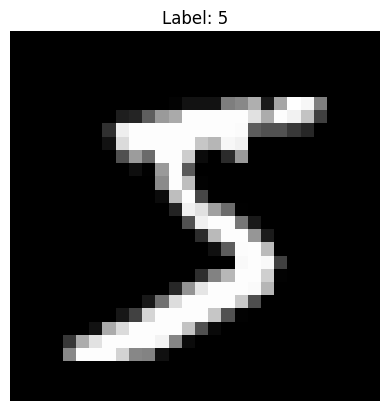

In [3]:
plt.imshow(X_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

In [4]:
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)
print(X_train.shape)

(60000, 784)


In [5]:
X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

In [6]:
def one_hot(y, num_classes=10):
    result = np.zeros((y.shape[0], num_classes))
    result[np.arange(y.shape[0]), y] = 1
    return result

Y_train = one_hot(y_train)
Y_test = one_hot(y_test)
print(Y_train.shape)
print(Y_train[0])

(60000, 10)
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [17]:
def relu(x):
    return np.maximum(0, x)
def relu_grad(x):
    return np.where(x > 0, 1.0, 0.0)

def softmax(x):
    x = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

def cross_entropy(y_true, y_pred):
    eps = 1e-12
    y_pred = np.clip(y_pred, eps, 1 - eps)
    #print(y_pred.shape)
    #print(y_true.shape)
    return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

**Initialize the MLP**

In [16]:
np.random.seed(42)
#he
W1 = np.random.randn(784, 128) * np.sqrt(2 / 784)
b1 = np.zeros((1, 128))
#print(W1.shape)
#print(b1.shape)
W2 = np.random.randn(128, 64) * np.sqrt(2 / 128)
b2 = np.zeros((1, 64))

W3 = np.random.randn(64, 10) * np.sqrt(2 / 64)
b3 = np.zeros((1, 10))

**Forward propagation**

In [18]:
def forward(X):
    z1 = X @ W1 + b1
    #print(z1.shape)
    a1 = relu(z1)

    z2 = a1 @ W2 + b2
    a2 = relu(z2)

    z3 = a2 @ W3 + b3
    y_pred = softmax(z3)

    cache = (X, z1, a1, z2, a2, z3, y_pred)

    return y_pred, cache

In [19]:
def backward(y_true, cache):
    X, z1, a1, z2, a2, z3, y_pred = cache

    m = X.shape[0]

    # Output layer
    #grad of loss w .r.t weighted sum
    dz3 = (y_pred - y_true) / m

    dW3 = a2.T @ dz3
    db3 = np.sum(dz3, axis=0, keepdims=True)

    # Hidden layer 2
    da2 = dz3 @ W3.T
    #local error
    dz2 = da2 * relu_grad(z2)

    dW2 = a1.T @ dz2
    db2 = np.sum(dz2, axis=0, keepdims=True)

    # Hidden layer 1
    da1 = dz2 @ W2.T
    dz1 = da1 * relu_grad(z1)

    dW1 = X.T @ dz1
    db1 = np.sum(dz1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2, dW3, db3

In [21]:
epochs = 10
batch_size = 64
learning_rate = 0.01

for epoch in range(epochs):

    # Shuffle training data
    indices = np.random.permutation(len(X_train))
    # The computer looks at indices [2, 0, 1]
    X_train_shuffled = X_train[indices]
    Y_train_shuffled = Y_train[indices]

    total_loss = 0

    for start in range(0, len(X_train), batch_size):

        end = start + batch_size

        X_batch = X_train_shuffled[start:end]
        Y_batch = Y_train_shuffled[start:end]

        # Forward propagation
        y_pred, cache = forward(X_batch)

        # Loss
        loss = cross_entropy(Y_batch, y_pred)
        total_loss += loss
        #print(np.mean(loss))

        # Backpropagation
        gradients = backward(Y_batch, cache)

        dW1, db1, dW2, db2, dW3, db3 = gradients

        # Weight update
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1

        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2

        W3 -= learning_rate * dW3
        b3 -= learning_rate * db3

    print(
        f"Epoch {epoch + 1}/{epochs}, "
        f"Loss: {total_loss:.4f}"
    )

Epoch 1/10, Loss: 259.2675
Epoch 2/10, Loss: 232.4516
Epoch 3/10, Loss: 211.4597
Epoch 4/10, Loss: 194.7358
Epoch 5/10, Loss: 180.7732
Epoch 6/10, Loss: 168.3371
Epoch 7/10, Loss: 157.7755
Epoch 8/10, Loss: 148.5867
Epoch 9/10, Loss: 140.2500
Epoch 10/10, Loss: 132.9757


In [12]:
y_test_pred, _ = forward(X_test)

predicted_labels = np.argmax(y_test_pred, axis=1)

accuracy = np.mean(predicted_labels == y_test)

print("Test accuracy:", accuracy)

Test accuracy: 0.9529
